Human single nucleus RNA sequencing: aggregated map
The top 2000 highly variable genes were calculated using in Seurat 3.1.5 (method=vst, n_genes=2000) followed by batch correction for each experiment using these highly variable genes with scVI (latent_dimension=50, max_epochs=300, early_stopping=True)(Lopez et al., 2018; Stuart et al., 2019). A neighborhood graph was constructed in scanpy using the latent embeddings of each nucleus from scVI with n_neighbors=15 and Euclidean distance(Wolf et al., 2018). A two dimensional visualization of the data was created with UMAP (min_dist=0.2) on this neighborhood graph. Nuclei in the aggregated map were clustered using the Leiden algorithm at resolution 0.4.


In [9]:
import os
from pathlib import Path

import scanpy as sc
import scvi

print(sc.__version__)
print(scvi.__version__)

workdir = Path(r"C:\Users\hunte\OneDrive\Desktop\R\Project\SCP2019\expression\raw")
os.chdir(workdir)
print("Working directory:", Path.cwd())


1.11.5
1.4.2
Working directory: C:\Users\hunte\OneDrive\Desktop\R\Project\SCP2019\expression\raw


C:\Users\hunte\AppData\Local\Temp\ipykernel_33004\2965603982.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [13]:
print(adata.var.head())
print(adata.var.columns.tolist())

                 n_cells  highly_variable  highly_variable_rank     means  \
ENSG00000187583       20             True                1895.0  0.005290   
ENSG00000205231        3             True                1573.0  0.000661   
ENSG00000186891        8             True                 188.0  0.002645   
ENSG00000182873        5             True                1954.0  0.001323   
ENSG00000149527        9             True                1263.0  0.002480   

                 variances  variances_norm  
ENSG00000187583   0.009231        1.213790  
ENSG00000205231   0.000992        1.226482  
ENSG00000186891   0.005615        1.469120  
ENSG00000182873   0.002313        1.213453  
ENSG00000149527   0.004458        1.244155  
['n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm']


In [2]:
import pandas as pd

# Load matrix, then transpose so rows are cells and columns are genes
adata = sc.read_mtx("Carotid_Expression_Matrix_raw_counts_V1.mtx").T

# Load feature and barcode names from TSV files
genes = pd.read_csv("Carotid_Expression_Matrix_genes_V1.tsv", sep="\t", header=None)
barcodes = pd.read_csv("Carotid_Expression_Matrix_Barcodes_V1.tsv", sep="\t", header=None)

adata.var_names = genes.iloc[:, 0].astype(str).values
adata.obs_names = barcodes.iloc[:, 0].astype(str).values

# Keep an untouched raw copy so downstream cells are safe to rerun
adata_raw = adata.copy()

print("Loaded adata with shape:", adata.shape)
print("First 3 genes:", adata.var_names[:3].tolist())
print("First 3 barcodes:", adata.obs_names[:3].tolist())

Loaded adata with shape: (6049, 33694)
First 3 genes: ['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092']
First 3 barcodes: ['AAACCCACAGACAAGC-1-0', 'AAACCCACAGAGGTAC-1-0', 'AAACCCATCTTACTGT-1-0']


c:\Users\hunte\miniconda3\envs\analysis\Lib\site-packages\scvi\data\fields\_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Using GPU: NVIDIA GeForce RTX 3060


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\hunte\miniconda3\envs\analysis\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\hunte\miniconda3\envs\analysis\Lib\site-packages\lightnin

Epoch 100/100: 100%|██████████| 100/100 [01:14<00:00,  1.35it/s, v_num=1, train_loss=234]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:14<00:00,  1.35it/s, v_num=1, train_loss=234]


C:\Users\hunte\AppData\Local\Temp\ipykernel_33004\235046483.py:36: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.4)


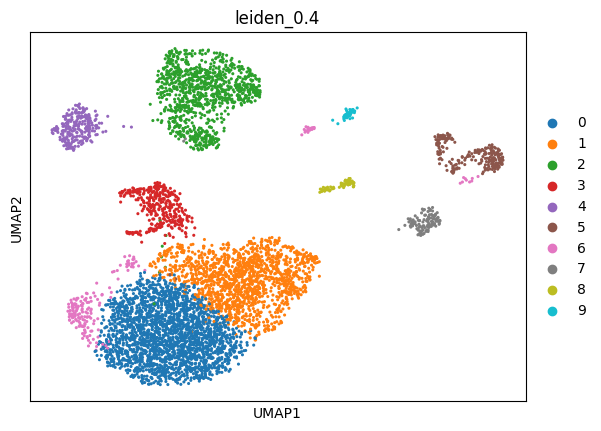

In [6]:
import scanpy as sc
import scvi
import torch

# Restore raw counts each run
adata = adata_raw.copy()
adata.layers["counts"] = adata.X.copy()

# Preprocessing
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    layer="counts",
    flavor="seurat_v3",
    subset=True,
)

# scVI
scvi.model.SCVI.setup_anndata(adata, layer="counts")
model = scvi.model.SCVI(adata)

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
    model.train(max_epochs=100, accelerator="gpu", devices=1)
else:
    print("GPU not detected in this environment. Training on CPU.")
    model.train(max_epochs=100, accelerator="cpu", devices=1)

adata.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=15, metric="euclidean")
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.4)
adata.obs["leiden_0.4"] = adata.obs["leiden"]
sc.pl.umap(adata, color="leiden_0.4")

In [7]:
adata.write_h5ad("project_leiden.h5ad")

In [8]:
import scanpy as sc
adata = sc.read_h5ad("project_leiden.h5ad")

In [10]:
import mygene

mg = mygene.MyGeneInfo()

# Get all Ensembl IDs
ensembl_ids = adata.var_names.tolist()

# Query symbols (this may take a minute)
results = mg.querymany(ensembl_ids, scopes="ensembl.gene", fields="symbol", species="human", returnall=False)

# Build mapping dictionary
id_to_symbol = {r["query"]: r.get("symbol", r["query"]) for r in results}

# Add as a column and replace index
adata.var["gene_symbol"] = [id_to_symbol.get(g, g) for g in adata.var_names]
adata.var_names = adata.var["gene_symbol"]
adata.var_names_make_unique()

# Verify
print(adata.var.head())

2 input query terms found dup hits:	[('ENSG00000234352', 2), ('ENSG00000276241', 4)]
87 input query terms found no hit:	['ENSG00000261135', 'ENSG00000231485', 'ENSG00000261737', 'ENSG00000237954', 'ENSG00000234283', 'ENS


             n_cells  highly_variable  highly_variable_rank     means  \
gene_symbol                                                             
PLEKHN1           20             True                1895.0  0.005290   
TTLL10-AS1         3             True                1573.0  0.000661   
TNFRSF18           8             True                 188.0  0.002645   
PRKCZ-AS1          5             True                1954.0  0.001323   
PLCH2              9             True                1263.0  0.002480   

             variances  variances_norm gene_symbol  
gene_symbol                                         
PLEKHN1       0.009231        1.213790     PLEKHN1  
TTLL10-AS1    0.000992        1.226482  TTLL10-AS1  
TNFRSF18      0.005615        1.469120    TNFRSF18  
PRKCZ-AS1     0.002313        1.213453   PRKCZ-AS1  
PLCH2         0.004458        1.244155       PLCH2  


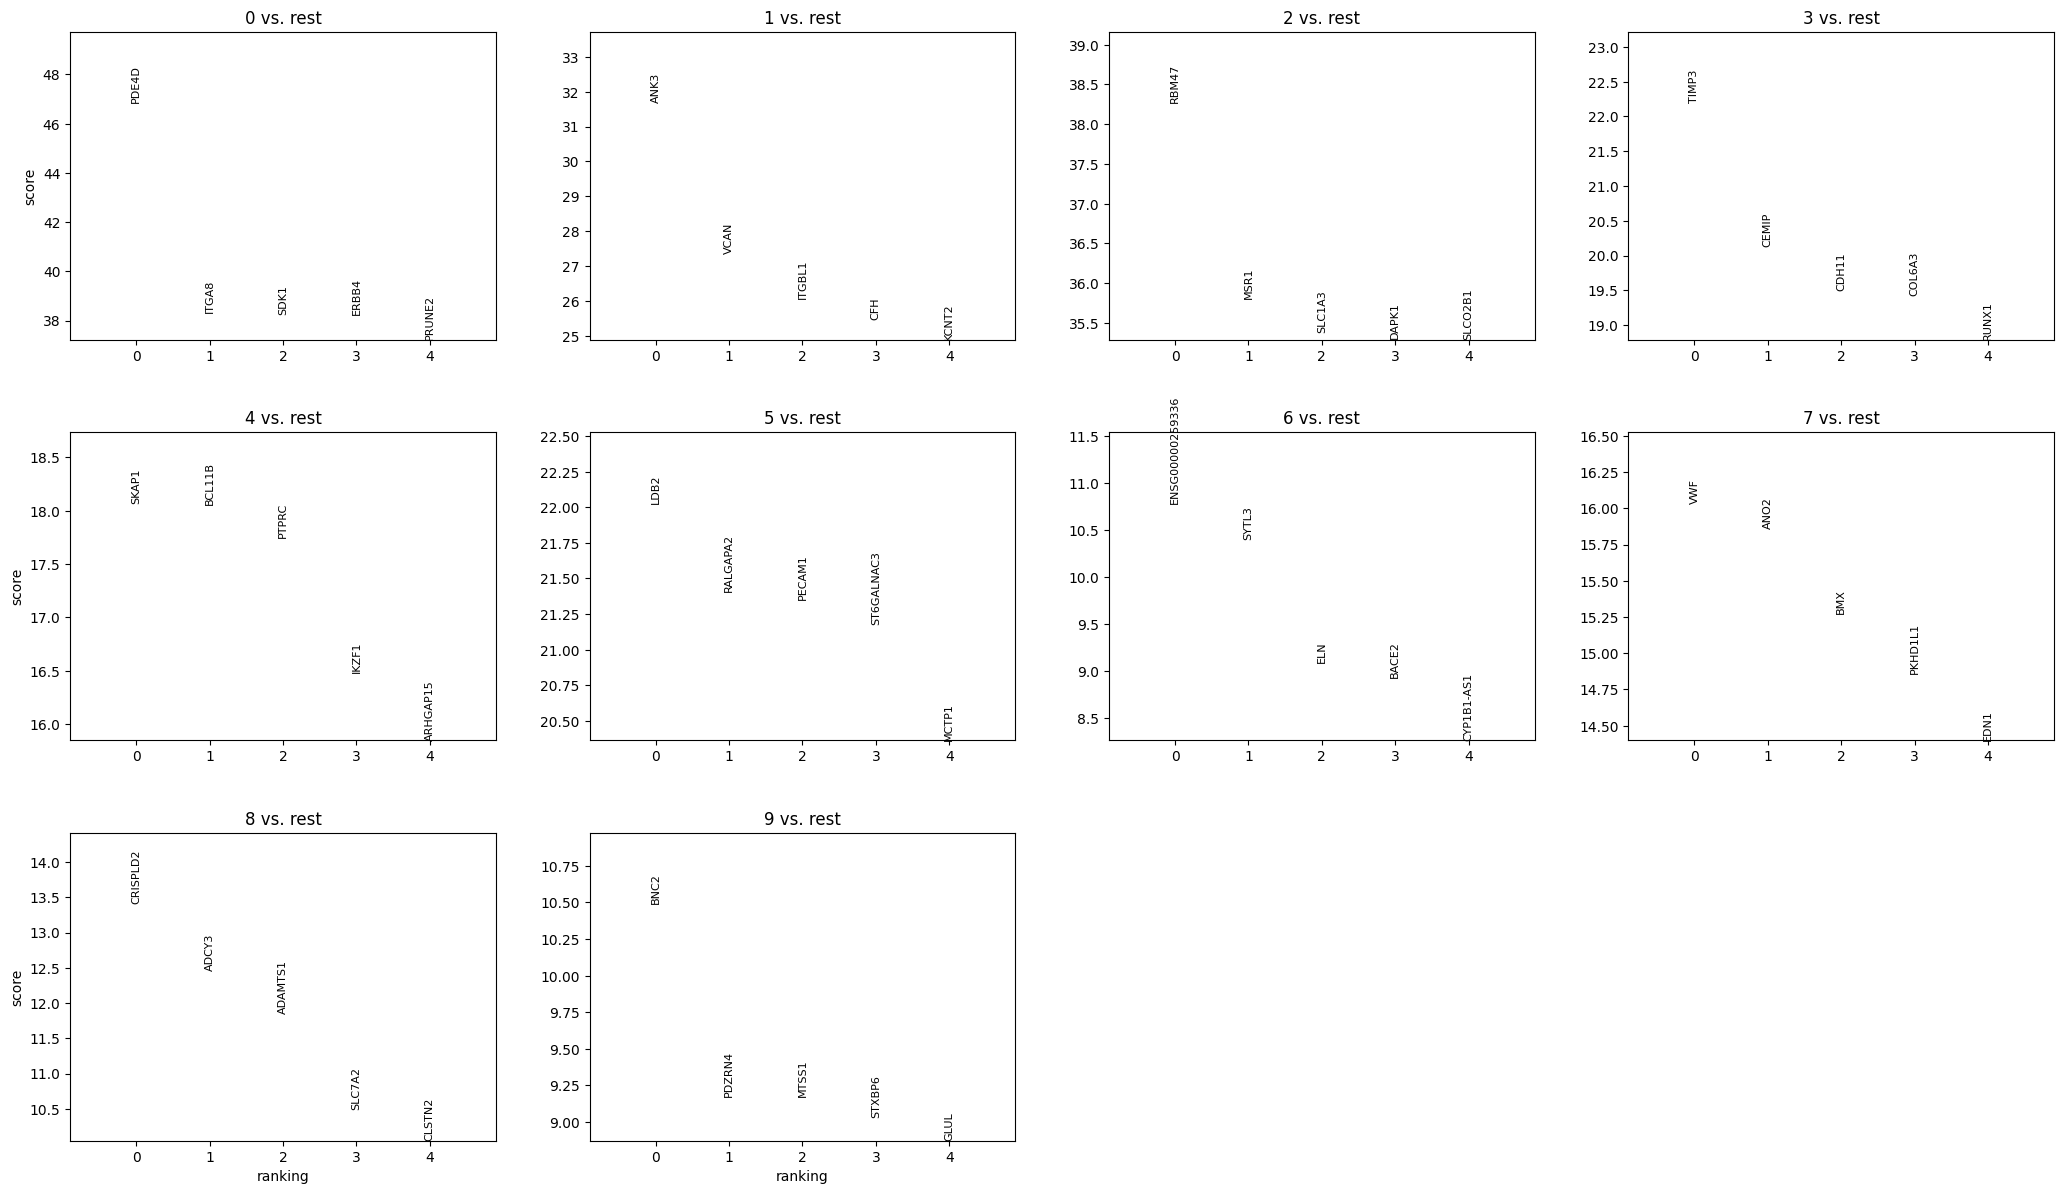

In [11]:
# Find marker genes for each cluster
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden_0.4",
    method="wilcoxon",    # robust, commonly used
    key_added="markers"
)

# Visualize top 5 markers per cluster
sc.pl.rank_genes_groups(adata, n_genes=5, key="markers", sharey=False)

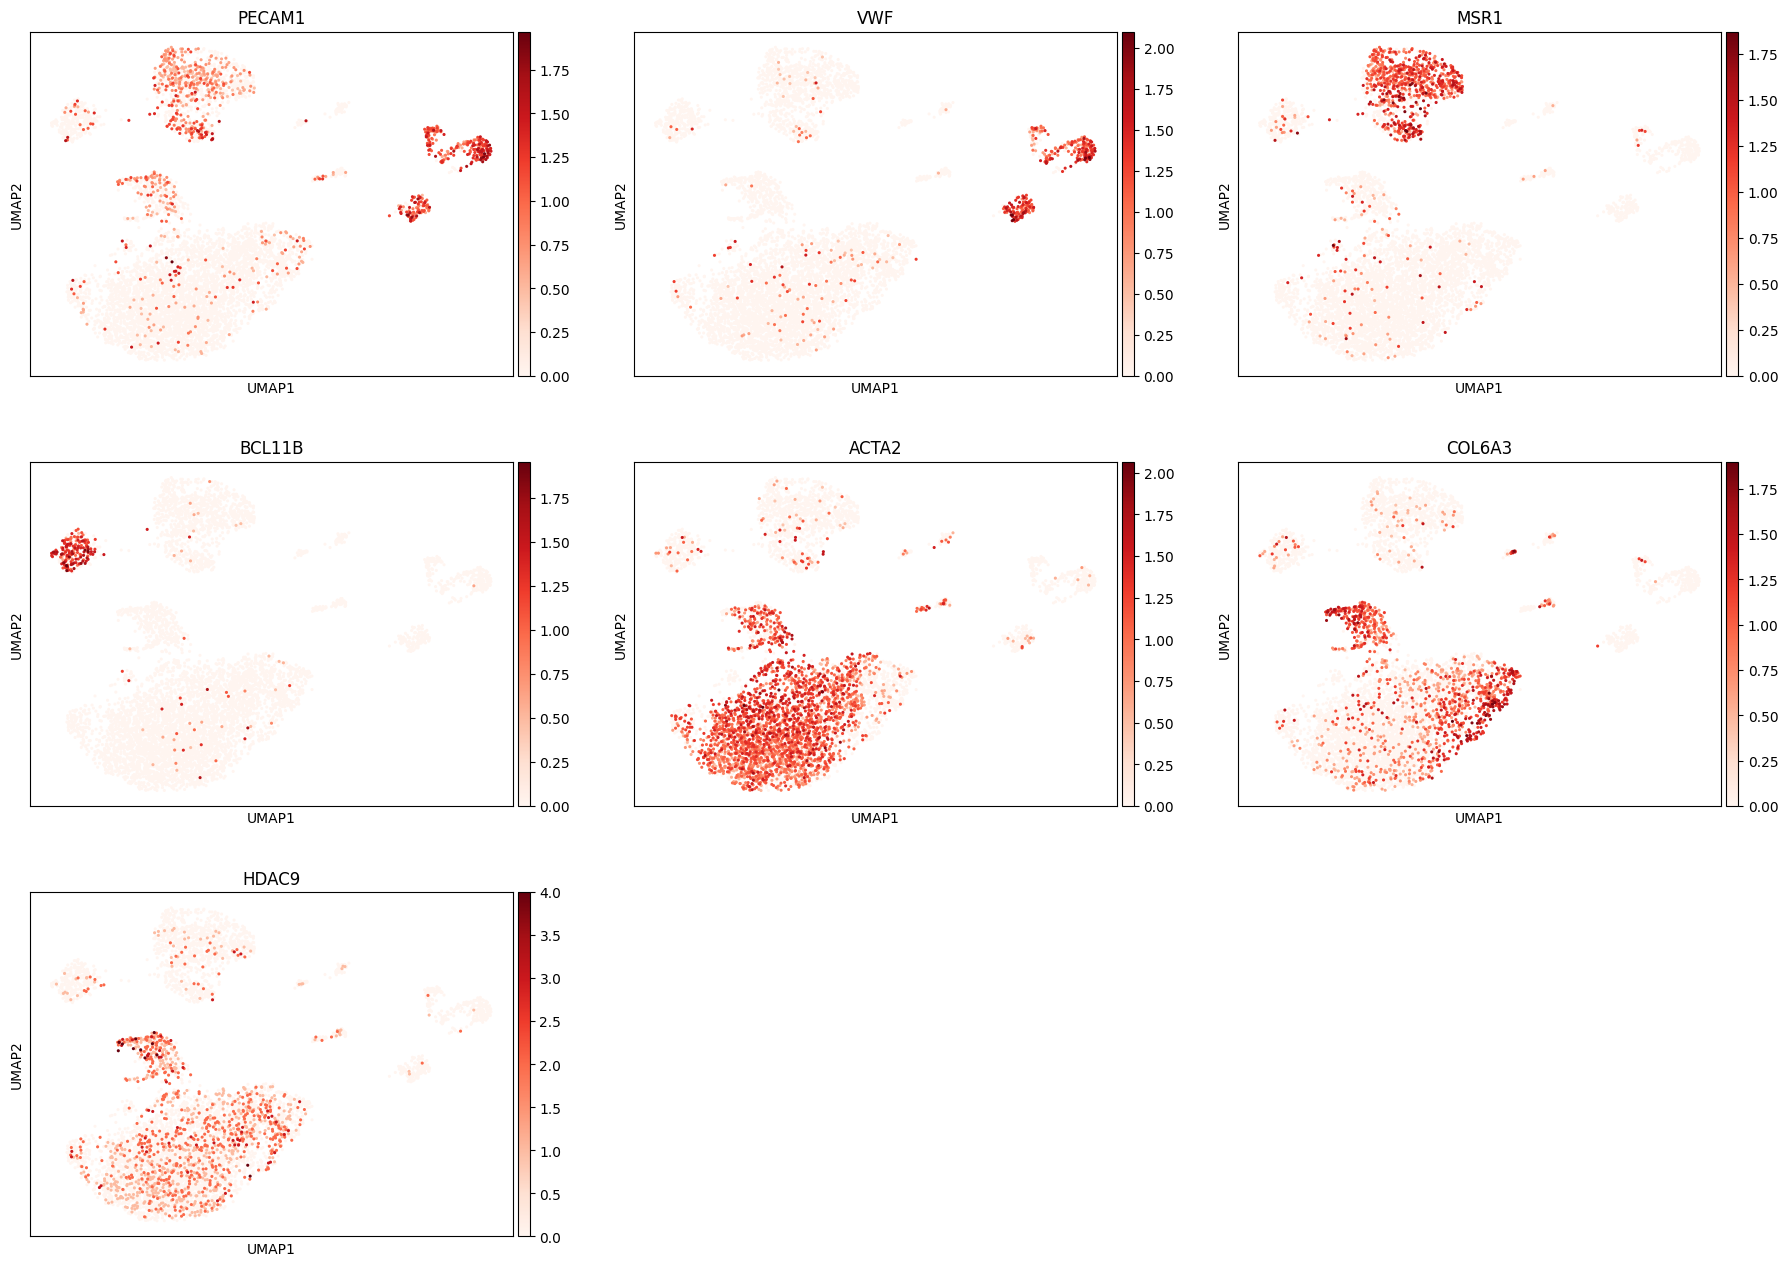

In [36]:
# Get HDAC9 expression from raw object
hdac9_expr = adata_raw[:, ensembl_id].X.toarray().flatten()

# Add to your processed adata's obs so you can plot it
shared_cells = adata.obs_names
adata.obs["HDAC9"] = hdac9_expr[adata_raw.obs_names.isin(shared_cells)]


# Overlay key canonical markers on UMAP
sc.pl.umap(adata, color=[
    "PECAM1",   # Endothelial
    "VWF",      # Endothelial
    "MSR1",     # Macrophage
    "BCL11B",   # T cell
    "ACTA2",    # VSMC contractile
    "COL6A3",   # Fibroblast
    "HDAC9"     #paper gene of interest
], ncols=3, color_map="Reds")

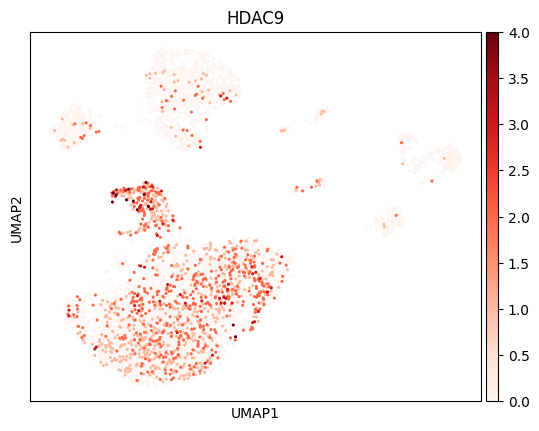

In [37]:
import numpy as np

# Get HDAC9 expression from raw object
hdac9_expr = adata_raw[:, ensembl_id].X.toarray().flatten()

# Add to your processed adata's obs so you can plot it
shared_cells = adata.obs_names
adata.obs["HDAC9"] = hdac9_expr[adata_raw.obs_names.isin(shared_cells)]

# Now plot
sc.pl.umap(adata, color="HDAC9", color_map="Reds")

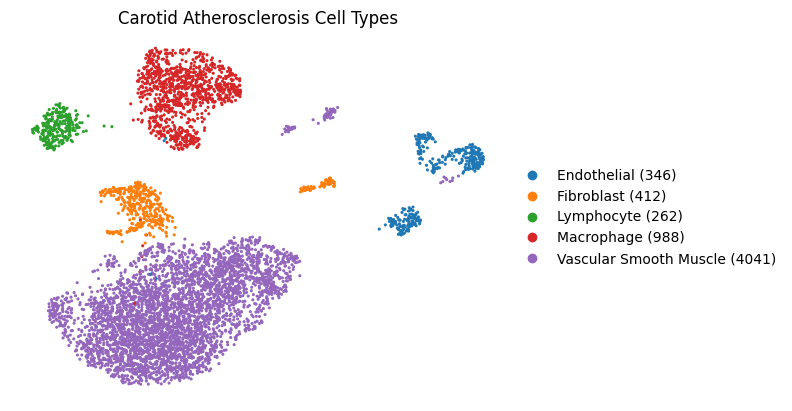

In [38]:
# Updated annotations matching the paper
cluster_annotations = {
    "0":  "Vascular Smooth Muscle",
    "1":  "Vascular Smooth Muscle",
    "2":  "Macrophage",
    "3":  "Fibroblast",
    "4":  "Lymphocyte",
    "5":  "Endothelial",
    "6":  "Vascular Smooth Muscle",
    "7":  "Endothelial",
    "8":  "Fibroblast",
    "9":  "Vascular Smooth Muscle",
    "10": "Unknown1"
}

# Create label with counts
counts = adata.obs["cell_type"].value_counts()
adata.obs["cell_type_labeled"] = adata.obs["cell_type"].map(
    lambda x: f"{x} ({counts[x]})"
)

adata.obs["cell_type"] = adata.obs["leiden_0.4"].map(cluster_annotations)

sc.pl.umap(
    adata,
    color="cell_type_labeled",
    legend_loc="right margin",
    legend_fontsize=10,
    frameon=False,
    title="Carotid Atherosclerosis Cell Types",
    save="carotid_celltypes.png"
)

In [39]:
# Option 2 - Cell counts
print(adata.obs["cell_type"].value_counts())

cell_type
Vascular Smooth Muscle    4041
Macrophage                 988
Fibroblast                 412
Endothelial                346
Lymphocyte                 262
Name: count, dtype: int64


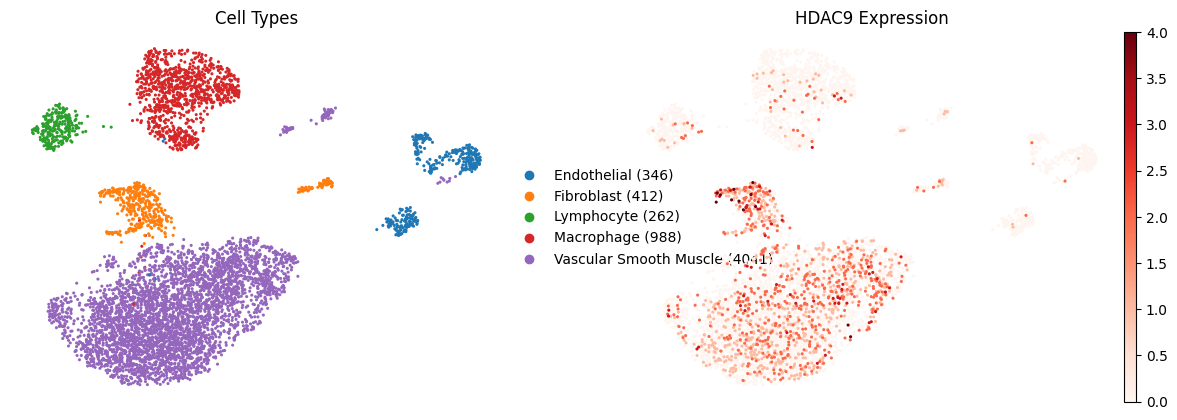

In [40]:
sc.pl.umap(
    adata,
    color=["cell_type_labeled", "HDAC9"],
    legend_loc="right margin",
    legend_fontsize=10,
    frameon=False,
    ncols=2,
    color_map="Reds",
    title=["Cell Types", "HDAC9 Expression"],
    save="carotid_HDAC9.png"
)

In [41]:
# Check which markers are available
all_markers = ["ACTA2", "MYH11", "TAGLN", "CNN1",
               "CD68", "MSR1", "CD14", "MRC1",
               "PECAM1", "VWF", "CDH5",
               "DCN", "LUM", "COL1A1", "COL6A3",
               "CD3D", "CD3E", "BCL11B", "IL7R"]

available = [g for g in all_markers if g in adata.var_names]
missing   = [g for g in all_markers if g not in adata.var_names]

print("Available:", available)
print("Missing:", missing)

Available: ['ACTA2', 'MYH11', 'MSR1', 'MRC1', 'PECAM1', 'VWF', 'DCN', 'LUM', 'COL6A3', 'CD3D', 'CD3E', 'BCL11B', 'IL7R']
Missing: ['TAGLN', 'CNN1', 'CD68', 'CD14', 'CDH5', 'COL1A1']


In [42]:
import mygene
mg = mygene.MyGeneInfo()

# Look up Ensembl IDs for missing genes
missing_genes = ["TAGLN", "CNN1", "CD68", "CD14", "CDH5", "COL1A1"]
results = mg.querymany(missing_genes, scopes="symbol", fields="ensembl.gene", species="human")

for r in results:
    symbol = r["query"]
    ensembl_id = r.get("ensembl", {})
    if isinstance(ensembl_id, list):
        ensembl_id = ensembl_id[0].get("gene", None)
    else:
        ensembl_id = ensembl_id.get("gene", None)
    
    if ensembl_id and ensembl_id in adata_raw.var_names:
        expr = adata_raw[adata.obs_names, ensembl_id].X.toarray().flatten()
        adata.obs[symbol] = expr
        print(f"✓ Added {symbol} ({ensembl_id})")
    else:
        print(f"✗ {symbol} not found in raw data ({ensembl_id})")

✓ Added TAGLN (ENSG00000149591)
✓ Added CNN1 (ENSG00000130176)
✓ Added CD68 (ENSG00000129226)
✓ Added CD14 (ENSG00000170458)
✓ Added CDH5 (ENSG00000179776)
✓ Added COL1A1 (ENSG00000108821)


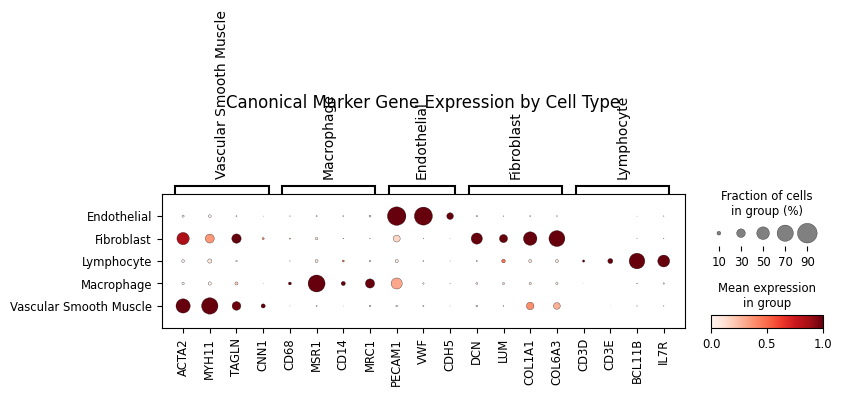

In [43]:
# Canonical markers for each cell type in this tissue
marker_genes = {
    "Vascular Smooth Muscle": ["ACTA2", "MYH11", "TAGLN", "CNN1"],
    "Macrophage":             ["CD68", "MSR1", "CD14", "MRC1"],
    "Endothelial":            ["PECAM1", "VWF", "CDH5"],
    "Fibroblast":             ["DCN", "LUM", "COL1A1", "COL6A3"],
    "Lymphocyte":             ["CD3D", "CD3E", "BCL11B", "IL7R"],
}

sc.pl.dotplot(
    adata,
    marker_genes,
    groupby="cell_type",
    dendrogram=False,
    color_map="Reds",
    standard_scale="var",   # scale each gene 0-1 for comparability
    title="Canonical Marker Gene Expression by Cell Type",
    save="carotid_dotplot.png"
)